# Markov Gaussian Processes — Matern Kernels in State-Space Form

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/markov_gp_sde_kernels.ipynb)

This notebook is the **first installment of pyrox's Markov-GP track**. It introduces `MaternSDE` — the state-space representation of the Matern-$\nu$ kernel for $\nu \in \{1/2, 3/2, 5/2\}$ — and verifies, end-to-end, that the SDE formulation and the dense kernel describe the *same* Gaussian process. Once a kernel is in state-space form, GP inference on a 1-D grid drops from $\mathcal{O}(N^3)$ Cholesky to $\mathcal{O}(N\,d^3)$ Kalman filtering, where $d \in \{1, 2, 3\}$ is the SDE state dimension.

Subsequent notebooks (issues #37 finish, #38) will compose SDE kernels, run Kalman / RTS smoothing, and expose `MarkovGPPrior` for NumPyro models. This one stays focused on the **representation layer**: math, identities, and visual sanity checks.

## Background — from kernel to SDE

Any *stationary* GP kernel $k(\tau)$ on $\mathbb{R}$ whose spectral density is rational in $\omega^2$ admits an exact, finite-dimensional state-space representation as a linear time-invariant SDE

$$d\mathbf{x}(t) = F\,\mathbf{x}(t)\,dt + L\,dw(t), \qquad f(t) = H\,\mathbf{x}(t),$$

with white-noise driver $w(t)$ of spectral density $Q_c$ and stationary state covariance $P_\infty$ solving the continuous Lyapunov equation

$$F P_\infty + P_\infty F^\top + L Q_c L^\top = 0.$$

Discretising at non-uniform observation times $t_1 < t_2 < \dots < t_N$ with $\Delta t_k = t_{k+1} - t_k$ gives the discrete-time linear-Gaussian model

$$\mathbf{x}_{k+1} = A_k \mathbf{x}_k + \mathbf{q}_k, \qquad \mathbf{q}_k \sim \mathcal{N}(0, Q_k), \qquad f_k = H\,\mathbf{x}_k,$$

with $A_k = \exp(F\,\Delta t_k)$ and $Q_k = P_\infty - A_k P_\infty A_k^\top$. The recovered continuous autocovariance is $k(\tau) = H \exp(F\tau) P_\infty H^\top$ for $\tau \geq 0$, which we will verify against the dense Matern kernel below.

### Matern-$\nu$ companion form

For Matern-$\nu$ with $\nu = p + 1/2$ and $\lambda = \sqrt{2\nu}/\ell$, the state has dimension $d = p + 1$ and $F$ is the companion matrix of $(\lambda + s)^d$. Concretely:

| Order $p$ | $\nu$ | $d$ | $\lambda$ | Closed-form kernel |
|---|---|---|---|---|
| 0 | 1/2 | 1 | $1/\ell$ | $\sigma^2 \exp(-r/\ell)$ |
| 1 | 3/2 | 2 | $\sqrt{3}/\ell$ | $\sigma^2 (1 + \sqrt{3} r/\ell)\exp(-\sqrt{3} r/\ell)$ |
| 2 | 5/2 | 3 | $\sqrt{5}/\ell$ | $\sigma^2 (1 + \sqrt{5} r/\ell + 5 r^2/(3\ell^2))\exp(-\sqrt{5} r/\ell)$ |

`MaternSDE` ships these three orders. Composition rules (sum / product), `CosineSDE`, `PeriodicSDE`, and the Kalman-based `MarkovGPPrior` follow in subsequent PRs.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg as jsl
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import MaternSDE
from pyrox.gp._src.kernels import matern_kernel


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,equinox,numpyro,pyrox,matplotlib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.7
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Inspecting the SDE parameters

A `MaternSDE(variance, lengthscale, order)` produces a closed-form $(F, L, H, Q_c, P_\infty)$ tuple via `sde_params()`. We instantiate one kernel per order and print the structural matrices alongside two structural identities:

1. **Variance recovery:** $H P_\infty H^\top = \sigma^2$.
2. **Lyapunov closure:** $F P_\infty + P_\infty F^\top + L Q_c L^\top = 0$.

In [4]:
sigma2 = 1.0
ell = 0.5
sdes = {p: MaternSDE(variance=sigma2, lengthscale=ell, order=p) for p in (0, 1, 2)}

for p, sde in sdes.items():
    F, L, H, Q_c, P_inf = sde.sde_params()
    var_rec = float((H @ P_inf @ H.T).squeeze())
    lyap = F @ P_inf + P_inf @ F.T + L @ Q_c @ L.T
    print(
        f"--- Matern-{int(2 * sde.nu)}/2  (order p = {p}, state dim d = {sde.state_dim}) ---"
    )
    print(f"F =\n{np.asarray(F)}")
    print(
        f"H = {np.asarray(H).ravel()},  L^T = {np.asarray(L).ravel()},  Q_c = {float(Q_c.squeeze()):.4f}"
    )
    print(f"P_inf =\n{np.asarray(P_inf)}")
    print(f"H P_inf H^T = {var_rec:.6f}  (expected sigma^2 = {sigma2})")
    print(
        f"||F P_inf + P_inf F^T + L Q_c L^T||_inf = {float(jnp.max(jnp.abs(lyap))):.2e}"
    )
    print()

--- Matern-1/2  (order p = 0, state dim d = 1) ---
F =
[[-2.]]
H = [1.],  L^T = [1.],  Q_c = 4.0000
P_inf =
[[1.]]
H P_inf H^T = 1.000000  (expected sigma^2 = 1.0)
||F P_inf + P_inf F^T + L Q_c L^T||_inf = 0.00e+00



--- Matern-3/2  (order p = 1, state dim d = 2) ---
F =
[[  0.           1.        ]
 [-12.          -6.92820323]]
H = [1. 0.],  L^T = [0. 1.],  Q_c = 166.2769
P_inf =
[[ 1.  0.]
 [ 0. 12.]]
H P_inf H^T = 1.000000  (expected sigma^2 = 1.0)
||F P_inf + P_inf F^T + L Q_c L^T||_inf = 0.00e+00



--- Matern-5/2  (order p = 2, state dim d = 3) ---
F =
[[  0.           1.           0.        ]
 [  0.           0.           1.        ]
 [-89.4427191  -60.         -13.41640786]]
H = [1. 0. 0.],  L^T = [0. 0. 1.],  Q_c = 9540.5567
P_inf =
[[  1.           0.          -6.66666667]
 [  0.           6.66666667   0.        ]
 [ -6.66666667   0.         400.        ]]
H P_inf H^T = 1.000000  (expected sigma^2 = 1.0)
||F P_inf + P_inf F^T + L Q_c L^T||_inf = 1.68e-15



Both invariants hold to machine precision in float64. The variance-recovery identity says the SDE state encodes the GP value plus $d-1$ derivative-like coordinates; the Lyapunov identity says the stationary state covariance is *consistent* with the drift $F$ and the diffusion $L Q_c L^\top$.

## 2. SDE autocovariance vs. dense Matern kernel

The continuous-time stationary autocovariance recovered from the SDE is

$$k_{\text{SDE}}(\tau) \;=\; H\,\exp(F \tau)\,P_\infty\,H^\top, \qquad \tau \geq 0.$$

This must equal the dense Matern Gram value at lag $\tau$. We compute both on a fine grid and overlay them.

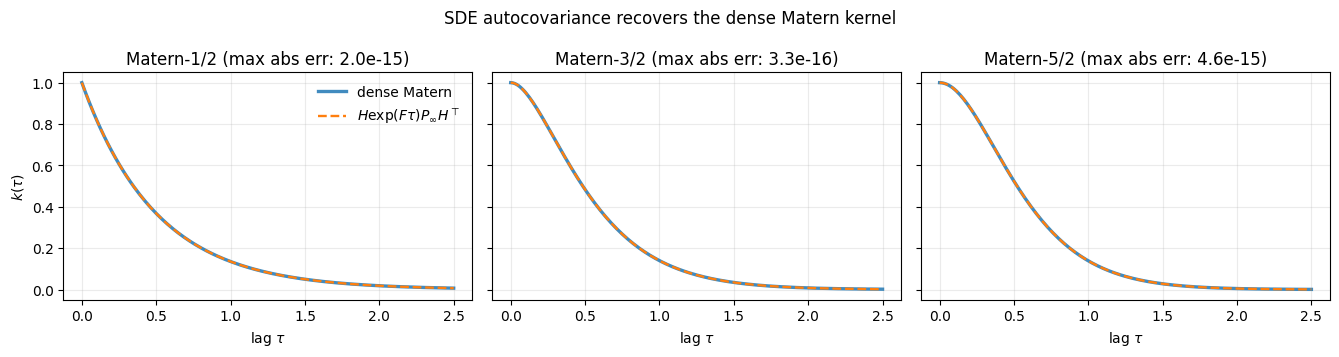

In [5]:
def sde_autocov(sde: MaternSDE, taus: jnp.ndarray) -> jnp.ndarray:
    F, _L, H, _Q_c, P_inf = sde.sde_params()

    def _k(tau: jnp.ndarray) -> jnp.ndarray:
        return (H @ jsl.expm(F * tau) @ P_inf @ H.T).squeeze()

    return jax.vmap(_k)(taus)


taus = jnp.linspace(0.0, 2.5, 201)
X = taus[:, None]
X0 = jnp.zeros((1, 1))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)
for ax, (p, sde) in zip(axes, sdes.items(), strict=False):
    k_sde = sde_autocov(sde, taus)
    k_dense = matern_kernel(
        X, X0, jnp.asarray(sigma2), jnp.asarray(ell), nu=p + 0.5
    ).squeeze()
    ax.plot(taus, k_dense, label="dense Matern", lw=2.4, alpha=0.85)
    ax.plot(taus, k_sde, "--", label=r"$H \exp(F\tau) P_\infty H^\top$", lw=1.7)
    err = float(jnp.max(jnp.abs(k_sde - k_dense)))
    ax.set_title(rf"Matern-{int(2 * sde.nu)}/2 (max abs err: {err:.1e})")
    ax.set_xlabel(r"lag $\tau$")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$k(\tau)$")
axes[0].legend(frameon=False, loc="upper right")
fig.suptitle("SDE autocovariance recovers the dense Matern kernel")
fig.tight_layout()
plt.show()

All three orders agree to numerical precision. The SDE is not an *approximation* of the Matern kernel — for $\nu \in \{1/2, 3/2, 5/2\}$ it is an exact reformulation.

## 3. Discretisation: $A_k$ and $Q_k$ as functions of $\Delta t$

Given a time step $\Delta t$, the discrete-time transition is $A(\Delta t) = \exp(F\,\Delta t)$ and the process-noise covariance is $Q(\Delta t) = P_\infty - A(\Delta t) P_\infty A(\Delta t)^\top$. Two endpoints are worth checking:

- As $\Delta t \to 0$, $A \to I$ and $Q \to 0$ (no time elapsed, no uncertainty added).
- As $\Delta t \to \infty$, $A P_\infty A^\top \to 0$ (the dynamics decay back to the stationary distribution) and so $Q \to P_\infty$ (the next state is independent of the previous one and has the stationary distribution).

We plot $\|A(\Delta t)\|_2$ and the trace of $Q(\Delta t)$ over a log-spaced range of step sizes.

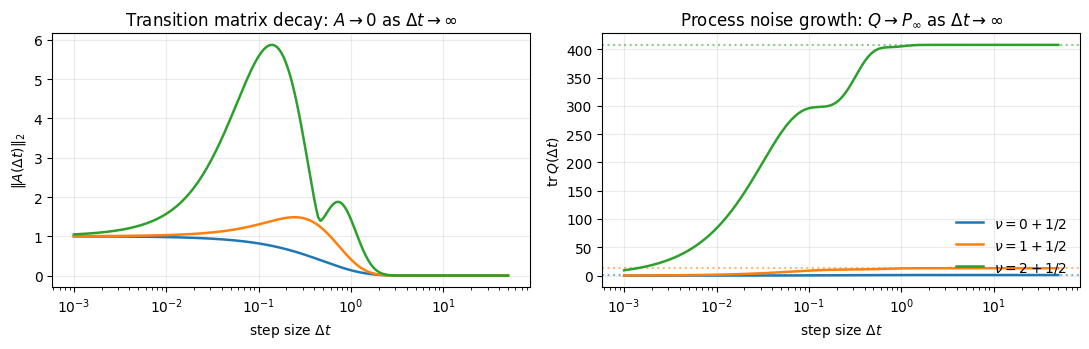

In [6]:
dts = jnp.geomspace(1e-3, 5e1, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for p, sde in sdes.items():
    A, Q = sde.discretise(dts)
    A_norm = jnp.linalg.norm(A, ord=2, axis=(1, 2))
    Q_trace = jnp.einsum("nii->n", Q)
    _, _, _, _, P_inf = sde.sde_params()
    P_inf_trace = float(jnp.trace(P_inf))
    label = rf"$\nu = {p}+1/2$"
    axes[0].plot(dts, A_norm, label=label, lw=1.8)
    axes[1].plot(dts, Q_trace, label=label, lw=1.8)
    axes[1].axhline(
        P_inf_trace, color=axes[1].lines[-1].get_color(), ls=":", alpha=0.55
    )

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel(r"step size $\Delta t$")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$\|A(\Delta t)\|_2$")
axes[0].set_title(r"Transition matrix decay: $A \to 0$ as $\Delta t \to \infty$")
axes[1].set_ylabel(r"$\mathrm{tr}\,Q(\Delta t)$")
axes[1].set_title(r"Process noise growth: $Q \to P_\infty$ as $\Delta t \to \infty$")
axes[1].legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

Dotted horizontal lines mark $\mathrm{tr}\,P_\infty$ for each order — the asymptote $Q$ relaxes onto. Higher-order Materns relax slower (more oscillatory state coordinates carry inertia), but the limit is the same.

## 4. Sample paths via forward simulation of the discrete-time SDE

We can draw GP sample paths *without ever forming a dense Gram matrix*. The recipe is the standard linear-Gaussian forward simulation of the discrete state-space model:

1. Sample $\mathbf{x}_0 \sim \mathcal{N}(0, P_\infty)$.
2. For $k = 0, 1, \dots, N-1$: sample $\mathbf{x}_{k+1} = A_k \mathbf{x}_k + \mathbf{q}_k$ with $\mathbf{q}_k \sim \mathcal{N}(0, Q_k)$.
3. Read out $f_k = H\,\mathbf{x}_k$.

All work is local in time; no $N \times N$ Cholesky. We compare paths drawn this way against paths drawn from the dense Matern Cholesky for the same time grid.

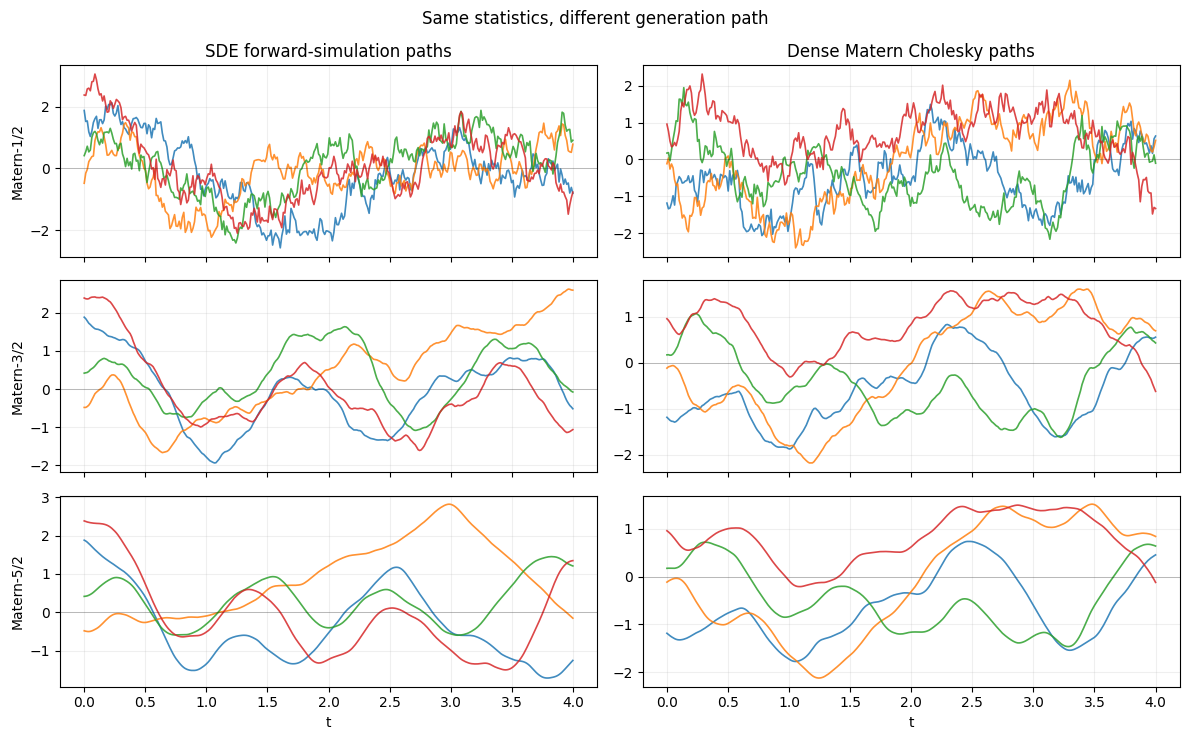

In [7]:
def sample_sde_paths(
    sde: MaternSDE,
    times: jnp.ndarray,
    n_paths: int,
    key: jax.Array,
) -> jnp.ndarray:
    """Forward-simulate ``n_paths`` realisations of the discrete state-space model."""
    _F, _L, H, _Q_c, P_inf = sde.sde_params()
    d = sde.state_dim
    dts = jnp.diff(times)
    A_all, Q_all = sde.discretise(dts)
    L_inf = jnp.linalg.cholesky(P_inf + 1e-10 * jnp.eye(d))
    L_step = jnp.linalg.cholesky(Q_all + 1e-10 * jnp.eye(d)[None])

    key_init, key_step = jr.split(key)
    x0 = L_inf @ jr.normal(key_init, (d, n_paths))  # (d, n_paths)
    eps = jr.normal(key_step, (dts.shape[0], d, n_paths))

    def step(
        x_prev: jnp.ndarray, inputs: tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]
    ) -> tuple[jnp.ndarray, jnp.ndarray]:
        A_k, L_k, eps_k = inputs
        x_next = A_k @ x_prev + L_k @ eps_k
        return x_next, x_next

    _, xs = jax.lax.scan(step, x0, (A_all, L_step, eps))
    states = jnp.concatenate([x0[None], xs], axis=0)  # (N, d, n_paths)
    f_paths = jnp.einsum("ij,njp->np", H, states)  # (N, n_paths)
    return f_paths


def sample_dense_paths(
    sde: MaternSDE,
    times: jnp.ndarray,
    n_paths: int,
    key: jax.Array,
) -> jnp.ndarray:
    X = times[:, None]
    K = matern_kernel(X, X, sde.variance, sde.lengthscale, nu=float(sde.nu))
    K = K + 1e-8 * jnp.eye(X.shape[0])
    L = jnp.linalg.cholesky(K)
    return L @ jr.normal(key, (X.shape[0], n_paths))


N = 320
times = jnp.linspace(0.0, 4.0, N)
n_paths = 4
seed = 0

fig, axes = plt.subplots(3, 2, figsize=(12, 7.5), sharex=True)
for row, (_p, sde) in enumerate(sdes.items()):
    sde_paths = sample_sde_paths(sde, times, n_paths, jr.PRNGKey(seed))
    dense_paths = sample_dense_paths(sde, times, n_paths, jr.PRNGKey(seed + 1))
    for j in range(n_paths):
        axes[row, 0].plot(times, sde_paths[:, j], lw=1.2, alpha=0.85)
        axes[row, 1].plot(times, dense_paths[:, j], lw=1.2, alpha=0.85)
    axes[row, 0].set_ylabel(rf"Matern-{int(2 * sde.nu)}/2")
    for ax in axes[row]:
        ax.grid(alpha=0.2)
        ax.axhline(0.0, color="k", lw=0.4, alpha=0.4)
axes[0, 0].set_title("SDE forward-simulation paths")
axes[0, 1].set_title("Dense Matern Cholesky paths")
for ax in axes[-1]:
    ax.set_xlabel("t")
fig.suptitle("Same statistics, different generation path")
fig.tight_layout()
plt.show()

Each row pairs the same kernel order; the seeds differ across columns so the realisations are independent draws. Visually the rougher Matern-1/2 paths sit on top, the smoother Matern-5/2 paths at the bottom, with the SDE and dense columns indistinguishable in their statistical character. The variances and correlation lengths match by construction.

## 5. Empirical covariance of SDE samples matches the analytic kernel

A stronger check than visual matching: estimate the covariance $\hat C_{ij} = \mathrm{Cov}[f(t_i), f(t_j)]$ from many SDE-simulated paths and compare to the closed-form Matern Gram on the same grid.

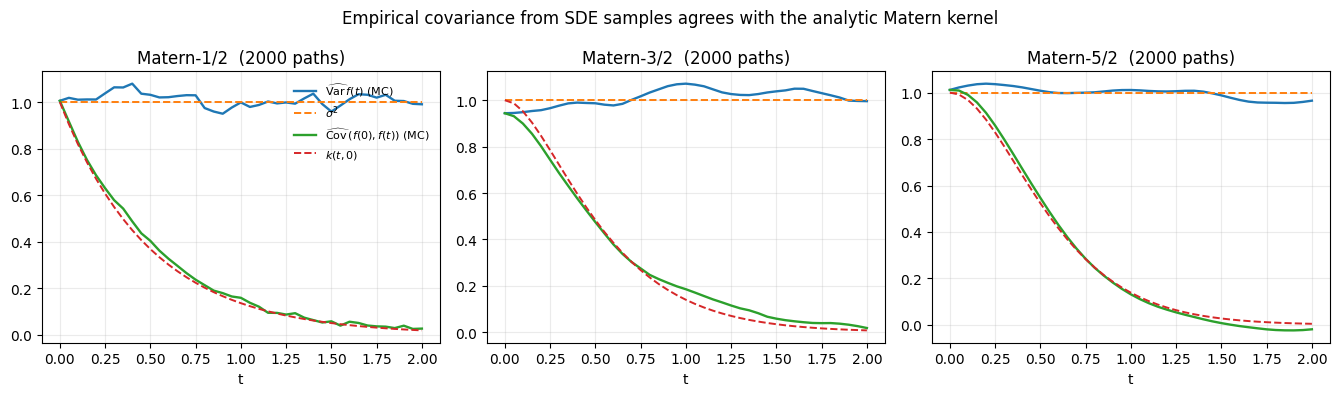

In [8]:
n_mc = 2000
mc_times = jnp.linspace(0.0, 2.0, 41)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for ax, (p, sde) in zip(axes, sdes.items(), strict=False):
    paths = sample_sde_paths(sde, mc_times, n_mc, jr.PRNGKey(11 + p))  # (N, n_mc)
    paths_centered = paths - paths.mean(axis=1, keepdims=True)
    C_emp = (paths_centered @ paths_centered.T) / (n_mc - 1)
    K_true = matern_kernel(
        mc_times[:, None],
        mc_times[:, None],
        sde.variance,
        sde.lengthscale,
        nu=float(sde.nu),
    )
    ax.plot(
        mc_times, jnp.diag(C_emp), label=r"$\widehat{\mathrm{Var}}\,f(t)$ (MC)", lw=1.7
    )
    ax.plot(mc_times, jnp.diag(K_true), "--", label=r"$\sigma^2$", lw=1.4)
    ax.plot(
        mc_times,
        C_emp[:, 0],
        lw=1.7,
        label=r"$\widehat{\mathrm{Cov}}\,(f(0), f(t))$ (MC)",
    )
    ax.plot(mc_times, K_true[:, 0], "--", lw=1.4, label=r"$k(t, 0)$")
    ax.set_title(rf"Matern-{int(2 * sde.nu)}/2  ({n_mc} paths)")
    ax.set_xlabel("t")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False, loc="upper right", fontsize=8)
fig.suptitle(
    "Empirical covariance from SDE samples agrees with the analytic Matern kernel"
)
fig.tight_layout()
plt.show()

Solid lines are Monte-Carlo estimates from $n_\text{mc} = 2000$ forward simulations; dashed lines are the closed-form values. They overlap to the precision afforded by 2000 samples.

## 6. The kernel zoo — primitives and composition rules

Matern alone is enough to cover smooth time series, but real signals usually have more structure: a fixed offset, a carrier oscillation, an annual cycle, a quasi-periodic modulation. State-space form scales gracefully here too — every additional kernel is *another small block* in the state, not another factor of $N$ in inference cost.

This section walks through the four new primitive / composition kernels added on top of `MaternSDE`:

| Class | Math | State dim |
|---|---|---|
| `ConstantSDE(σ²)` | $k(\tau) = \sigma^2$ | 1 |
| `CosineSDE(σ², ω)` | $k(\tau) = \sigma^2 \cos(\omega\,\tau)$ | 2 |
| `PeriodicSDE(σ², ℓ, T, J)` | MacKay periodic, Fourier-truncated to $J$ harmonics | $1 + 2J$ |
| `SumSDE((k₁, …))` | $k(\tau) = \sum_i k_i(\tau)$ | $\sum_i d_i$ |
| `ProductSDE(k₁, k₂)` | $k(\tau) = k_1(\tau)\,k_2(\tau)$ | $d_1 \cdot d_2$ |
| `QuasiPeriodicSDE(matern, periodic)` | thin wrapper for `ProductSDE` | $d_M (1 + 2J)$ |

`SumSDE` is block-diagonal in $F$, $L$, $Q_c$ and $P_\infty$, with the readouts $H$ concatenated. `ProductSDE` uses Kronecker-sum drift $F = F_1 \otimes I + I \otimes F_2$ and Kronecker-product readout / stationary covariance $H = H_1 \otimes H_2$, $P_\infty = P_{\infty,1} \otimes P_{\infty,2}$. The diffusion is a sum of two Kronecker terms — see the `ProductSDE` docstring for the full formula.

In [9]:
from pyrox.gp import (
    ConstantSDE,
    CosineSDE,
    PeriodicSDE,
    ProductSDE,
    QuasiPeriodicSDE,
    SumSDE,
)
from pyrox.gp._src.kernels import periodic_kernel

### 6.1 Building blocks: ConstantSDE, CosineSDE, PeriodicSDE

We instantiate one of each, draw a few sample paths via the same forward-simulation recipe used for Matern in §4, and overlay the SDE autocovariance against a dense reference where one is available. `PeriodicSDE` uses `n_harmonics = 7` — enough to match the MacKay periodic kernel to better than 1e-4 in the typical hyperparameter regime.

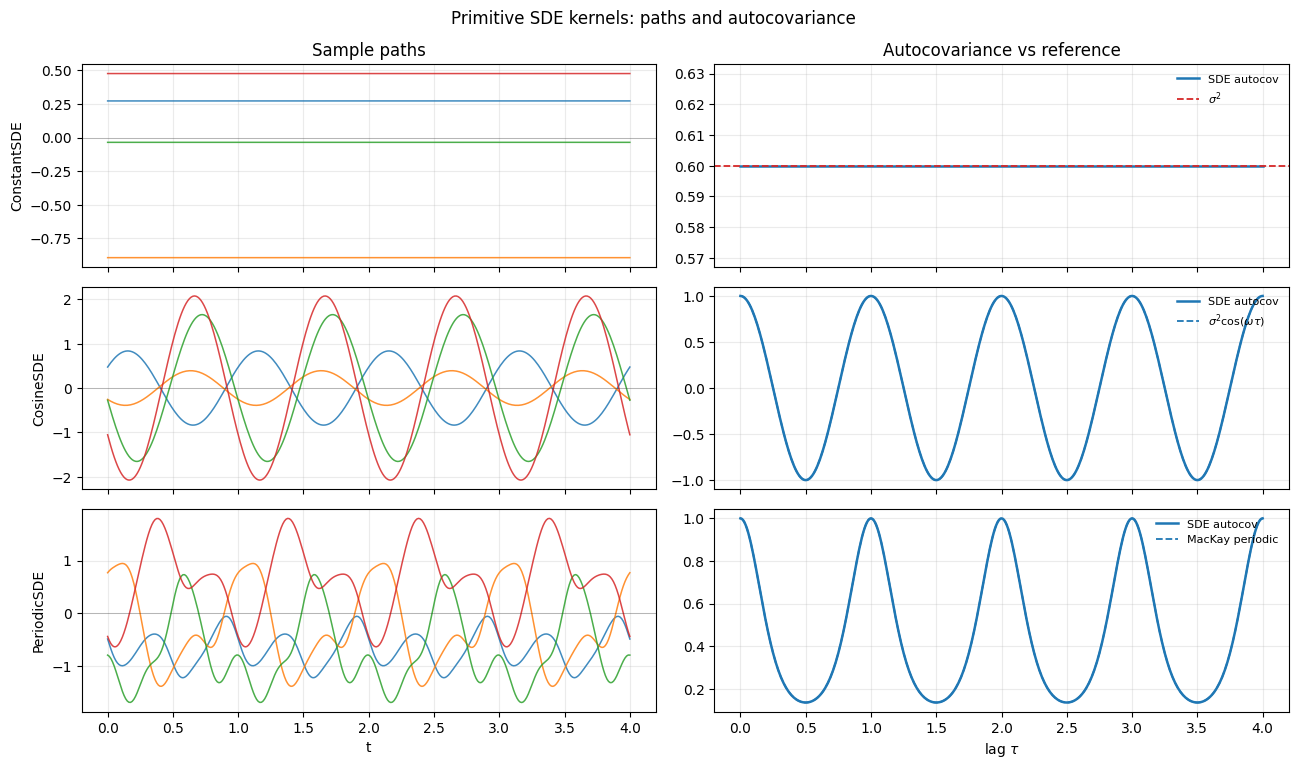

In [10]:
const = ConstantSDE(variance=0.6)
cos = CosineSDE(variance=1.0, frequency=2.0 * jnp.pi)  # period 1
per = PeriodicSDE(variance=1.0, lengthscale=1.0, period=1.0, n_harmonics=7)

primitives = {"ConstantSDE": const, "CosineSDE": cos, "PeriodicSDE": per}

times_demo = jnp.linspace(0.0, 4.0, 320)
fig, axes = plt.subplots(3, 2, figsize=(13, 7.8), sharex="col")
for row, (name, sde) in enumerate(primitives.items()):
    paths = sample_sde_paths(sde, times_demo, n_paths=4, key=jr.PRNGKey(7 + row))
    for j in range(4):
        axes[row, 0].plot(times_demo, paths[:, j], lw=1.1, alpha=0.85)
    axes[row, 0].set_ylabel(name)
    axes[row, 0].grid(alpha=0.25)
    axes[row, 0].axhline(0.0, color="k", lw=0.4, alpha=0.4)

    F, _L, H, _Q_c, P_inf = sde.sde_params()
    taus_demo = jnp.linspace(0.0, 4.0, 401)
    K_sde = jax.vmap(
        lambda t, F=F, H=H, P_inf=P_inf: (H @ jsl.expm(F * t) @ P_inf @ H.T).squeeze()
    )(taus_demo)
    axes[row, 1].plot(taus_demo, K_sde, lw=1.8, label="SDE autocov", color="C0")
    if name == "ConstantSDE":
        axes[row, 1].axhline(0.6, ls="--", lw=1.3, color="C3", label=r"$\sigma^2$")
    elif name == "CosineSDE":
        axes[row, 1].plot(
            taus_demo,
            jnp.cos(2.0 * jnp.pi * taus_demo),
            "--",
            lw=1.3,
            label=r"$\sigma^2 \cos(\omega\tau)$",
        )
    else:
        K_dense = periodic_kernel(
            taus_demo[:, None],
            jnp.zeros((1, 1)),
            jnp.asarray(1.0),
            jnp.asarray(1.0),
            jnp.asarray(1.0),
        ).squeeze()
        axes[row, 1].plot(taus_demo, K_dense, "--", lw=1.3, label="MacKay periodic")
    axes[row, 1].grid(alpha=0.25)
    axes[row, 1].legend(frameon=False, loc="upper right", fontsize=8)
axes[0, 0].set_title("Sample paths")
axes[0, 1].set_title("Autocovariance vs reference")
for ax in axes[-1]:
    ax.set_xlabel("t" if ax is axes[-1, 0] else r"lag $\tau$")
fig.suptitle("Primitive SDE kernels: paths and autocovariance")
fig.tight_layout()
plt.show()

- `ConstantSDE` paths are flat realisations: each draw is a single Gaussian random variable replicated across time. The autocovariance is the constant $\sigma^2$.
- `CosineSDE` paths are pure sinusoids with random amplitude and phase. The covariance oscillates exactly as $\sigma^2 \cos(\omega\tau)$.
- `PeriodicSDE` paths are smooth, period-aware, and *not* sinusoidal — they live in the function space of the MacKay periodic kernel. Truncating the Fourier expansion at $J=7$ matches the dense kernel within plotting precision.

### 6.2 Composition: trend + offset via `SumSDE`

A common modelling pattern is "smooth trend on top of a fixed offset". With dense kernels this is one line: `RBF + Constant`. In state-space form it's exactly the same — just `SumSDE`. The block-diagonal construction keeps each component's state space disjoint, so the cost is purely additive ($\sum_i d_i$).

SumSDE state dim: 3  (= 2 + 1)


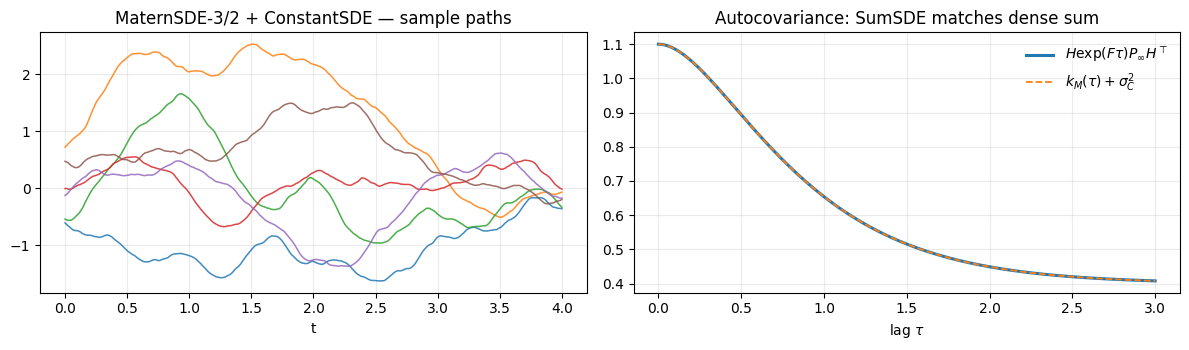

In [11]:
trend = SumSDE(
    (
        MaternSDE(variance=0.7, lengthscale=0.8, order=1),
        ConstantSDE(variance=0.4),
    )
)
print(f"SumSDE state dim: {trend.state_dim}  (= 2 + 1)")

paths = sample_sde_paths(trend, times_demo, n_paths=6, key=jr.PRNGKey(33))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for j in range(6):
    axes[0].plot(times_demo, paths[:, j], lw=1.1, alpha=0.85)
axes[0].set_title("MaternSDE-3/2 + ConstantSDE — sample paths")
axes[0].set_xlabel("t")
axes[0].grid(alpha=0.25)

F, _L, H, _Q_c, P_inf = trend.sde_params()
taus_demo = jnp.linspace(0.0, 3.0, 301)
K_sum = jax.vmap(lambda t: (H @ jsl.expm(F * t) @ P_inf @ H.T).squeeze())(taus_demo)
K_truth = (
    matern_kernel(
        taus_demo[:, None],
        jnp.zeros((1, 1)),
        jnp.asarray(0.7),
        jnp.asarray(0.8),
        nu=1.5,
    ).squeeze()
    + 0.4
)
axes[1].plot(taus_demo, K_sum, lw=2.2, label=r"$H \exp(F\tau) P_\infty H^\top$")
axes[1].plot(taus_demo, K_truth, "--", lw=1.3, label=r"$k_M(\tau) + \sigma_C^2$")
axes[1].set_title("Autocovariance: SumSDE matches dense sum")
axes[1].set_xlabel(r"lag $\tau$")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

Sample paths show the Matern wiggle riding on independently-drawn constant offsets — exactly the prior we wanted. The autocovariance recovers $k_{\rm Matern}(\tau) + \sigma_C^2$ to machine precision.

### 6.3 Composition: damped oscillation via `ProductSDE`

The product of a Matern and a Cosine is the *subband Matern* kernel — a stationary kernel whose spectral density is centred on a non-zero carrier $\omega_0$. It's the right prior for narrowband oscillatory signals (audio harmonics, geophysical resonances, modulated sensor traces). State dim is $d_M \cdot d_C$ — for Matern-3/2 × Cosine that's $2 \cdot 2 = 4$.

ProductSDE state dim: 4


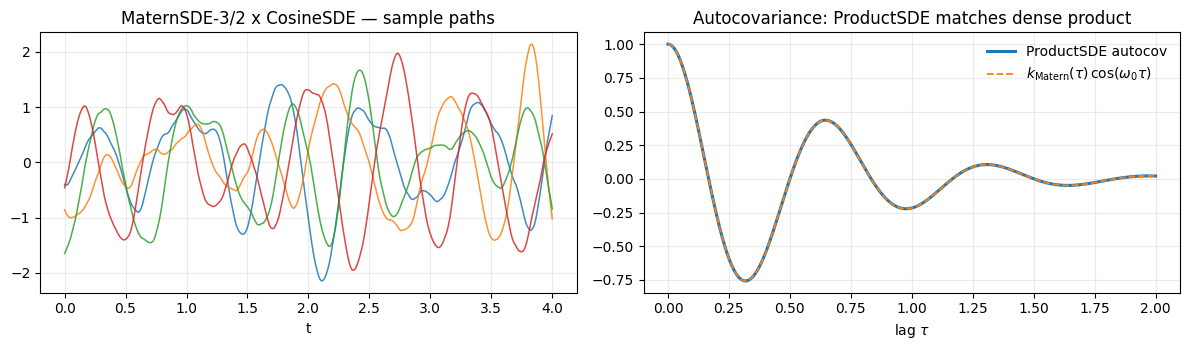

In [12]:
damped = ProductSDE(
    MaternSDE(variance=1.0, lengthscale=0.6, order=1),
    CosineSDE(variance=1.0, frequency=2.0 * jnp.pi * 1.5),  # 1.5 Hz carrier
)
print(f"ProductSDE state dim: {damped.state_dim}")

paths = sample_sde_paths(damped, times_demo, n_paths=4, key=jr.PRNGKey(101))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for j in range(4):
    axes[0].plot(times_demo, paths[:, j], lw=1.1, alpha=0.85)
axes[0].set_title("MaternSDE-3/2 x CosineSDE — sample paths")
axes[0].set_xlabel("t")
axes[0].grid(alpha=0.25)

F, _L, H, _Q_c, P_inf = damped.sde_params()
taus_demo = jnp.linspace(0.0, 2.0, 401)
K_prod = jax.vmap(lambda t: (H @ jsl.expm(F * t) @ P_inf @ H.T).squeeze())(taus_demo)
K_m = matern_kernel(
    taus_demo[:, None], jnp.zeros((1, 1)), jnp.asarray(1.0), jnp.asarray(0.6), nu=1.5
).squeeze()
K_c = jnp.cos(2.0 * jnp.pi * 1.5 * taus_demo)
axes[1].plot(taus_demo, K_prod, lw=2.2, label=r"ProductSDE autocov")
axes[1].plot(
    taus_demo,
    K_m * K_c,
    "--",
    lw=1.3,
    label=r"$k_{\rm Matern}(\tau)\,\cos(\omega_0\tau)$",
)
axes[1].set_title("Autocovariance: ProductSDE matches dense product")
axes[1].set_xlabel(r"lag $\tau$")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

The paths are oscillations whose envelope drifts on the Matern lengthscale — a damped carrier signal. The product autocovariance matches $k_M(\tau) \cos(\omega_0 \tau)$ to numerical precision (the slight curvature of the envelope reflects the Matern factor).

### 6.4 Quasi-periodic kernels — modulated periodic structure

The classic "stellar" prior: a periodic signal whose amplitude drifts slowly over time. Mathematically it's $k_{\rm Matern}(\tau) \cdot k_{\rm Periodic}(\tau)$ — a `ProductSDE` of two stationary kernels. `QuasiPeriodicSDE` is just a thin convenience wrapper that documents the standard recipe.

QuasiPeriodicSDE state dim: 22  (= 2 * (1 + 2*5))


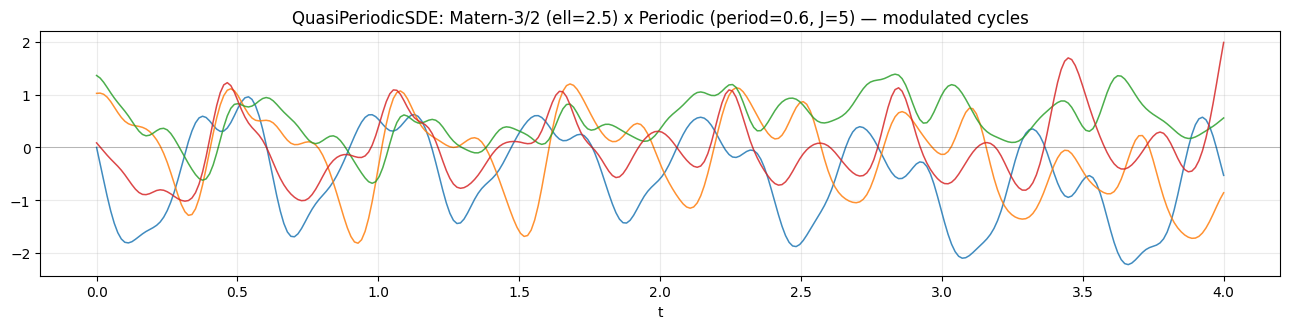

In [13]:
qp = QuasiPeriodicSDE(
    MaternSDE(variance=1.0, lengthscale=2.5, order=1),  # slow envelope (long ell)
    PeriodicSDE(variance=1.0, lengthscale=1.0, period=0.6, n_harmonics=5),
)
print(f"QuasiPeriodicSDE state dim: {qp.state_dim}  (= 2 * (1 + 2*5))")

paths = sample_sde_paths(qp, times_demo, n_paths=4, key=jr.PRNGKey(57))

fig, ax = plt.subplots(1, 1, figsize=(13, 3.4))
for j in range(4):
    ax.plot(times_demo, paths[:, j], lw=1.1, alpha=0.85)
ax.set_title(
    "QuasiPeriodicSDE: Matern-3/2 (ell=2.5) x Periodic (period=0.6, J=5) — modulated cycles"
)
ax.set_xlabel("t")
ax.axhline(0.0, color="k", lw=0.4, alpha=0.4)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

Each draw shows a clear period of about 0.6 time units, but the amplitude drifts on a slow Matern timescale — short bursts of high-amplitude oscillation followed by quiescent stretches, exactly the prior class used for stellar light curves and modulated seasonal signals.

## What this PR ships and what comes next

**PR 1 (issue #37 partial, #112 — already merged).** The `SDEKernel` protocol and the `MaternSDE` family for $\nu \in \{1/2, 3/2, 5/2\}$.

**This PR (issue #37 finish).** The kernel zoo on top of `MaternSDE`:

- **Primitives:** `ConstantSDE`, `CosineSDE` (closed-form rotation `discretise`), `PeriodicSDE` (Solin & Sarkka 2014, Fourier-truncated MacKay periodic kernel via a stable log-space Bessel helper).
- **Composition rules:** `SumSDE` (block-diagonal) and `ProductSDE` (Kronecker-sum drift, Kronecker-product readout / stationary covariance, with the diffusion matrix derived from the Lyapunov identity).
- **Convenience:** `QuasiPeriodicSDE` as a documented `ProductSDE(MaternSDE, PeriodicSDE)`.

**Next up — issue #38.** `MarkovGPPrior` plus the Kalman filter / RTS smoother. Once that lands, every kernel above can be plugged directly into a NumPyro model with linear-time temporal inference: ``f = numpyro.sample("f", MarkovGPPrior(QuasiPeriodicSDE(...), times))``.

**References.**

1. Sarkka, S. & Solin, A. (2019). *Applied Stochastic Differential Equations.* Cambridge University Press, Ch. 12.
2. Hartikainen, J. & Sarkka, S. (2010). *Kalman Filtering and Smoothing Solutions to Temporal Gaussian Process Regression Models.* IEEE MLSP.
3. Solin, A. & Sarkka, S. (2014). *Explicit Link Between Periodic Covariance Functions and State Space Models.* AISTATS.
4. Wilkinson, W. J., Sarkka, S. & Solin, A. (2023). *Bayes-Newton Methods for Approximate Bayesian Inference with PSD Guarantees.* JMLR 24(83).